# Finite Difference Method for Quantum Mechanics

## Imports


In [53]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg
from scipy.sparse.linalg import eigsh
import time
import finite_difference_quantum as fin
import quantum_testing_utils as qtu


## Finite Difference Functions


## Timing Comparison: 2nd vs 4th Order Methods


## Convergence Analysis: 4th Order Method


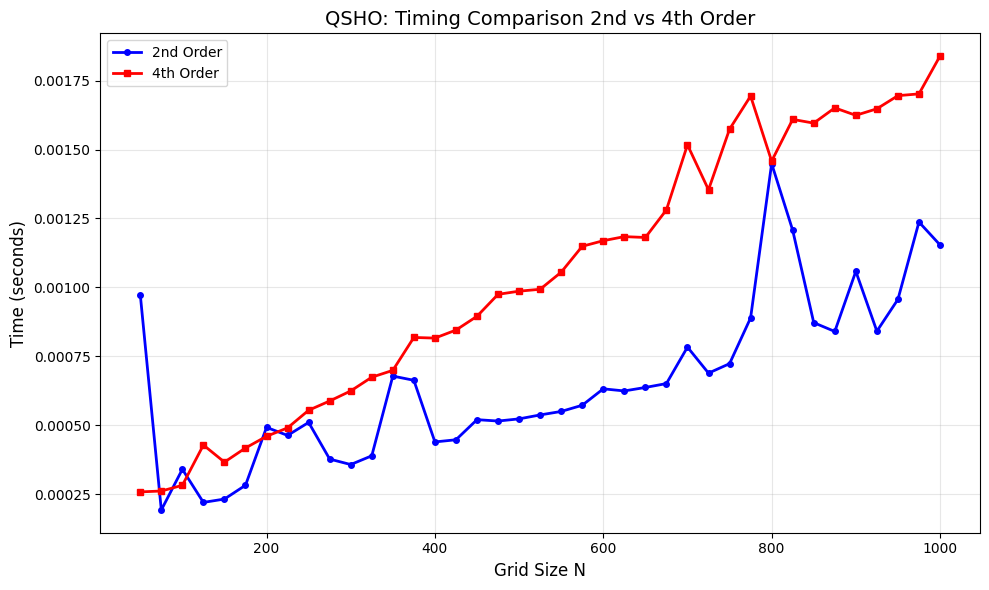

In [54]:
# Timing analysis using testing utilities
def V_QSHO(x): 
    return 0.5 * x**2

x_left, x_right = -5.0, 5.0
N_values = np.arange(50, 1001, 25)

# Use testing utilities for timing analysis
timing_2nd = qtu.timing_analysis(fin.hamiltonian, N_values, V_QSHO, x_left, x_right, order=2)
timing_4th = qtu.timing_analysis(fin.hamiltonian, N_values, V_QSHO, x_left, x_right, order=4)

# Plot timing comparison using testing utilities
qtu.plot_timing_comparison(N_values, timing_2nd, timing_4th, 
                          title="QSHO: Timing Comparison 2nd vs 4th Order")



## Convergence Analysis: 4th Order Method


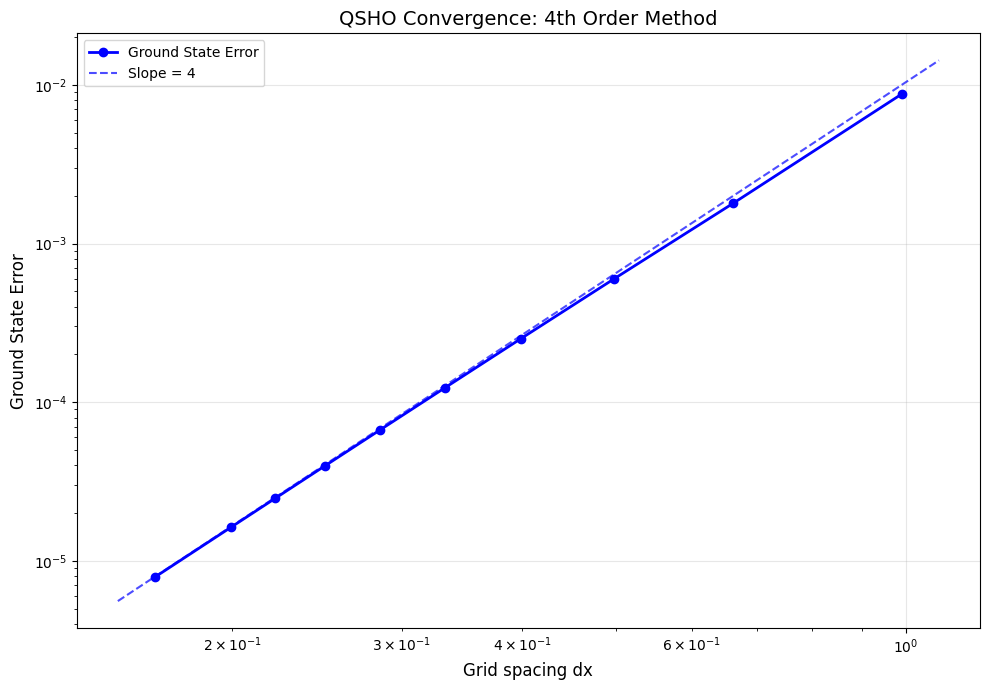

Convergence rate: 3.92 (expected: 4.0)


In [55]:
# Convergence analysis using testing utilities
def V_QSHO(x): 
    return 0.5 * x**2

x_inf = 100.0 
x_left, x_right = -x_inf, x_inf

N_list = [201, 301, 401, 501, 601, 701, 801, 901, 1001, 1201]
errs, dxs = [], []

for N_test in N_list:
    Ht = fin.hamiltonian_4th(V_QSHO, x_left, x_right, N_test)
    Et, _ = eigsh(Ht, k=1, which='SM', tol=1e-10, maxiter=2000)
    Et = np.min(Et)
    grid_t = fin.spatial(x_left, x_right, N_test)
    dx = grid_t[1] - grid_t[0]
    
    # Use analytical solution from testing utilities
    E0_exact = qtu.analytical_QSHO_eigenvalues(1)[0]  # Ground state
    error = abs(Et - E0_exact)
    
    dxs.append(dx)
    errs.append(error)

# Plot convergence using testing utilities
qtu.plot_convergence(dxs, errs, 
                    title="QSHO Convergence: 4th Order Method",
                    xlabel="Grid spacing dx", 
                    ylabel="Ground State Error",
                    reference_slopes=[4],  # Expected 4th order convergence
                    labels=["Ground State Error"])

# Calculate convergence rate
rate = qtu.convergence_rate(dxs, errs)
print(f"Convergence rate: {rate:.2f} (expected: 4.0)")


## Matrix Verification Test


In [56]:
x_left, x_right = 1.0, 2.0
N = 4

def A(x): return 2*x
def B(x): return x**2  
def C(x): return 1.0

grid = fin.spatial(x_left, x_right, N)
print(f"Grid points: {grid}")
print(f"Grid spacing Δ = {grid[1] - grid[0]:.3f}")
print()

a_vals = fin.proj(A, grid)
b_vals = fin.proj(B, grid) 
c_vals = fin.proj(C, grid)

print(f"A(x) values: {a_vals}")
print(f"B(x) values: {b_vals}")
print(f"C(x) values: {c_vals}")
print()


Grid points: [1.2 1.4 1.6 1.8]
Grid spacing Δ = 0.200

A(x) values: [2.4+0.j 2.8+0.j 3.2+0.j 3.6+0.j]
B(x) values: [1.44+0.j 1.96+0.j 2.56+0.j 3.24+0.j]
C(x) values: [1.+0.j 1.+0.j 1.+0.j 1.+0.j]



In [57]:
actual_2nd = fin.sparseMatrixMaker(A, B, C, grid).toarray()
print("Actual 2nd order matrix:")
print(actual_2nd)
print()


Actual 2nd order matrix:
[[  61. +0.j   67.2+0.j    0. +0.j    0. +0.j]
 [-149.8+0.j   71. +0.j   79.8+0.j    0. +0.j]
 [   0. +0.j -172.8+0.j   81. +0.j   92.8+0.j]
 [   0. +0.j    0. +0.j -196.2+0.j   91. +0.j]]



In [58]:
actual_4th = fin.sparse_Matrix_Maker4(A, B, C, grid).toarray()
print("Actual 4th order matrix:")
print(actual_4th)
print()


Actual 4th order matrix:
[[-122.6       +0.j   67.2       +0.j   -1.2       +0.j    0.        +0.j]
 [  86.8       +0.j -174.        +0.j   99.86666667+0.j   -6.65      +0.j]
 [  -5.6       +0.j   98.13333333+0.j -199.        +0.j  115.2       +0.j]
 [   0.        +0.j    2.7       +0.j   73.8       +0.j -170.9       +0.j]]

